#  Projet de Machine Learning — Performances des Étudiants

**Dataset :** StudentsPerformance.csv  
**Auteur :** Étudiant UCA Marrakech — Cours Prof. Kalloubi  
**Objectif :** Appliquer l'ensemble des algorithmes ML vus en cours sur un dataset réel

##  Plan du notebook

| # | Section | Algorithmes |
|||-|
| 0 | Imports | — |
| 1 | Exploration & Préparation (EDA) | — |
| 2 | Modèles Linéaires | Ridge, Lasso, Elastic-Net, Logistic Regression |
| 3 | Arbres de Décision | CART, Gini Index |
| 4 | KNN | K-Nearest Neighbors |
| 5 | Ensemble Learning | Random Forest, AdaBoost, Gradient Boosting |
| 6 | Méthodes Rule-Based | Extraction de règles, RIPPER |
| 7 | Clustering (Non supervisé) | K-Means, Hiérarchique, DBSCAN |
| 8 | Évaluation Complète | ROC, AUC, Cross-Validation, Comparaison |

## 0.  Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    AdaBoostClassifier, GradientBoostingClassifier,
    GradientBoostingRegressor
)

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
    mean_squared_error, r2_score, mean_absolute_error,
    classification_report
)

try:
    import wittgenstein as lw
    RIPPER_AVAILABLE = True
except ImportError:
    RIPPER_AVAILABLE = False
    print('wittgenstein non disponible — section RIPPER ignorée')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

print('✅ Tous les imports réussis !')

✅ Tous les imports réussis !


## 1.  Exploration des données

### 1.1 Chargement et aperçu

In [2]:
# Chargement du dataset
df = pd.read_csv('StudentsPerformance.csv')

print(f'📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'🔍 Valeurs manquantes : {df.isnull().sum().sum()}')
print()
df.head(10)

📐 Dimensions : 1000 lignes × 8 colonnes
🔍 Valeurs manquantes : 0



,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [3]:
# Types et valeurs uniques
print('=== Types & Valeurs uniques ===')
for col in df.columns:
    print(f'{col:40s} | dtype: {str(df[col].dtype):8s} | unique: {df[col].nunique()}')

=== Types & Valeurs uniques ===
gender                                   | dtype: str      | unique: 2
race/ethnicity                           | dtype: str      | unique: 5
parental level of education              | dtype: str      | unique: 6
lunch                                    | dtype: str      | unique: 2
test preparation course                  | dtype: str      | unique: 2
math score                               | dtype: int64    | unique: 81
reading score                            | dtype: int64    | unique: 72
writing score                            | dtype: int64    | unique: 77


In [4]:
# Statistiques des scores
df[['math score', 'reading score', 'writing score']].describe().round(2)

,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


### 1.2 Visualisations exploratoires

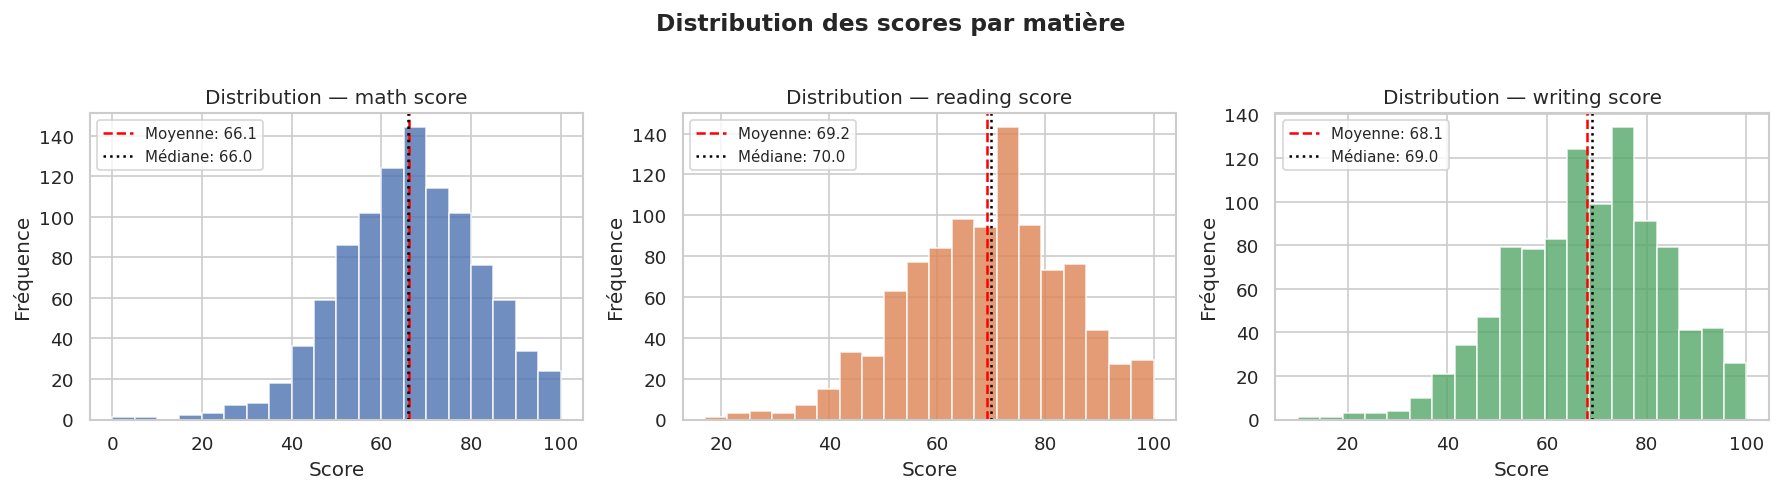

In [5]:
# Distribution des scores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
scores = ['math score', 'reading score', 'writing score']
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, score, color in zip(axes, scores, colors):
    ax.hist(df[score], bins=20, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df[score].mean(), color='red', linestyle='--', label=f'Moyenne: {df[score].mean():.1f}')
    ax.axvline(df[score].median(), color='black', linestyle=':', label=f'Médiane: {df[score].median():.1f}')
    ax.set_title(f'Distribution — {score}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=9)

plt.suptitle('Distribution des scores par matière', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

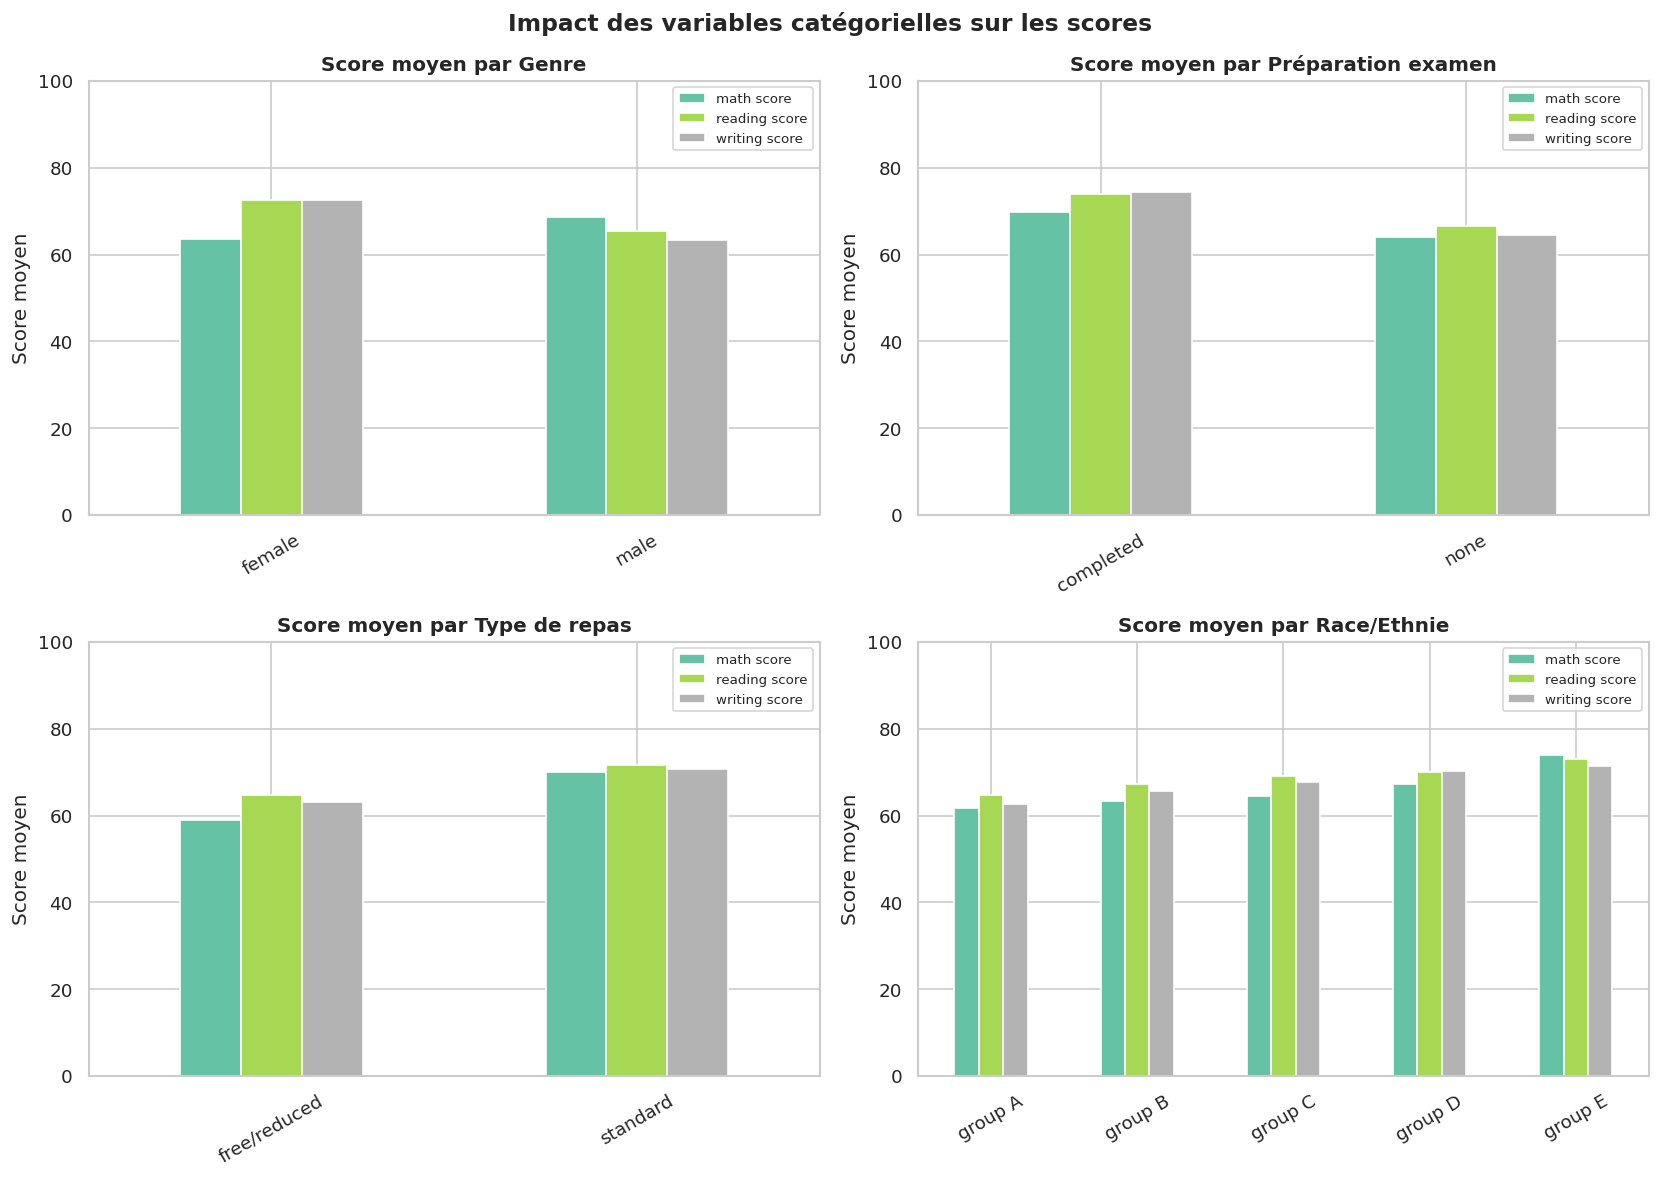

In [6]:
# Scores moyens par variable catégorielle
cat_vars = [
    ('gender', 'Genre'),
    ('test preparation course', 'Préparation examen'),
    ('lunch', 'Type de repas'),
    ('race/ethnicity', 'Race/Ethnie')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, cat_vars):
    means = df.groupby(col)[['math score', 'reading score', 'writing score']].mean()
    means.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(f'Score moyen par {title}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score moyen')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 100)

plt.suptitle('Impact des variables catégorielles sur les scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

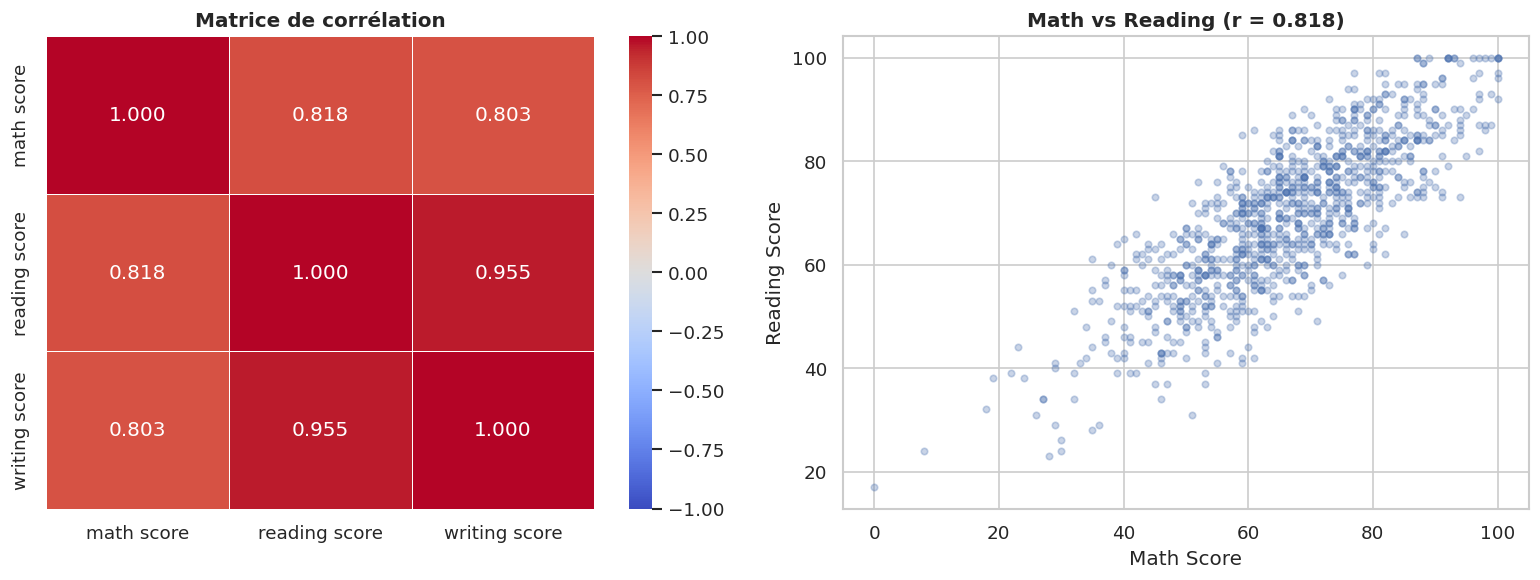

💡 Observation : Reading et Writing sont très fortement corrélés (r=0.955).
   Math est également bien corrélé aux deux autres (r≈0.81).


In [7]:
# Matrice de corrélation entre les scores
corr = df[['math score', 'reading score', 'writing score']].corr()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Matrice de corrélation', fontweight='bold')

# Scatter matrix
axes[1].scatter(df['math score'], df['reading score'], alpha=0.3, s=15, color='#4C72B0')
axes[1].set_xlabel('Math Score')
axes[1].set_ylabel('Reading Score')
axes[1].set_title(f'Math vs Reading (r = {corr.loc["math score","reading score"]:.3f})', fontweight='bold')

plt.tight_layout()
plt.show()

print('💡 Observation : Reading et Writing sont très fortement corrélés (r=0.955).')
print('   Math est également bien corrélé aux deux autres (r≈0.81).')

### 1.3 Feature Engineering & Encodage

In [8]:
df['avg_score']  = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

# Binary target: pass (avg >= 60) / fail
df['pass_fail'] = (df['avg_score'] >= 60).astype(int)   # 1=pass, 0=fail

# 3-class target: faible / moyen / fort
df['level'] = pd.cut(df['avg_score'],
                     bins=[0, 50, 70, 100],
                     labels=['Faible', 'Moyen', 'Fort'])

print('Répartition Pass/Fail :')
print(df['pass_fail'].value_counts().rename({1:'Pass (≥60)', 0:'Fail (<60)'}), '\n')
print('Répartition Niveaux :')
print(df['level'].value_counts())

Répartition Pass/Fail :
pass_fail
Pass (≥60)    715
Fail (<60)    285
Name: count, dtype: int64 

Répartition Niveaux :
level
Fort      447
Moyen     444
Faible    109
Name: count, dtype: int64


In [9]:
df_enc = df.copy()

# Label encoding for ordinal variable (parental education)
edu_order = {
    'some high school': 0,
    'high school': 1,
    'some college': 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}
df_enc['parental_edu_num'] = df_enc['parental level of education'].map(edu_order)

# Binary encoding
df_enc['gender_num']   = (df_enc['gender'] == 'female').astype(int)
df_enc['lunch_num']    = (df_enc['lunch'] == 'standard').astype(int)
df_enc['testprep_num'] = (df_enc['test preparation course'] == 'completed').astype(int)

# One-hot for race/ethnicity
df_enc = pd.get_dummies(df_enc, columns=['race/ethnicity'], prefix='race', drop_first=False)

# Feature list for models
FEATURES = ['gender_num', 'lunch_num', 'testprep_num', 'parental_edu_num',
            'race_group A', 'race_group B', 'race_group C', 'race_group D', 'race_group E']

TARGET_REG  = 'math score'          # regression target
TARGET_CLF  = 'pass_fail'           # binary classification target

print('✅ Encodage terminé')
print(f'Features : {FEATURES}')
df_enc[FEATURES + [TARGET_REG, TARGET_CLF]].head(5)

✅ Encodage terminé
Features : ['gender_num', 'lunch_num', 'testprep_num', 'parental_edu_num', 'race_group A', 'race_group B', 'race_group C', 'race_group D', 'race_group E']


,gender_num,lunch_num,testprep_num,parental_edu_num,race_group A,race_group B,race_group C,race_group D,race_group E,math score,pass_fail
0,1,1,0,4,False,True,False,False,False,72,1
1,1,1,1,2,False,False,True,False,False,69,1
2,1,1,0,5,False,True,False,False,False,90,1
3,0,0,0,3,True,False,False,False,False,47,0
4,0,1,0,2,False,False,True,False,False,76,1


In [10]:
X = df_enc[FEATURES].astype(float)
y_reg = df_enc[TARGET_REG].astype(float)   # continuous
y_clf = df_enc[TARGET_CLF].astype(int)     # binary

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE)

X_train_c, X_test_c, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

# Scaled versions (for KNN, Logistic Regression)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train size : {X_train.shape[0]} | Test size : {X_test.shape[0]}')
print(f'Pass rate (train) : {y_train_clf.mean():.2%}')
print(f'Pass rate (test)  : {y_test_clf.mean():.2%}')

Train size : 800 | Test size : 200
Pass rate (train) : 71.50%
Pass rate (test)  : 71.50%


## 2.  Modèles Linéaires

Les modèles linéaires supposent une relation linéaire entre les features et la cible.  
Formule générale : **f(X) = w₁x₁ + w₂x₂ + … + wₚxₚ + w₀**

### 2.1 Régression — Prédire le Math Score

In [11]:
reg_models = {
    'OLS (Baseline)' : LinearRegression(),
    'Ridge (L2)'     : Ridge(alpha=1.0),
    'Lasso (L1)'     : Lasso(alpha=0.1),
    'Elastic-Net'    : ElasticNet(alpha=0.1, l1_ratio=0.5)
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train_s, y_train_reg)
    preds = model.predict(X_test_s)
    reg_results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, preds)),
        'MAE' : mean_absolute_error(y_test_reg, preds),
        'R²'  : r2_score(y_test_reg, preds)
    }

df_reg_results = pd.DataFrame(reg_results).T.round(4)
print('=== Résultats Régression ===')
df_reg_results

=== Résultats Régression ===


,RMSE,MAE,R²
OLS (Baseline),14.0525,11.1556,0.1885
Ridge (L2),14.0520,11.1553,0.1885
Lasso (L1),14.0721,11.1791,0.1862
Elastic-Net,14.0471,11.1534,0.1891


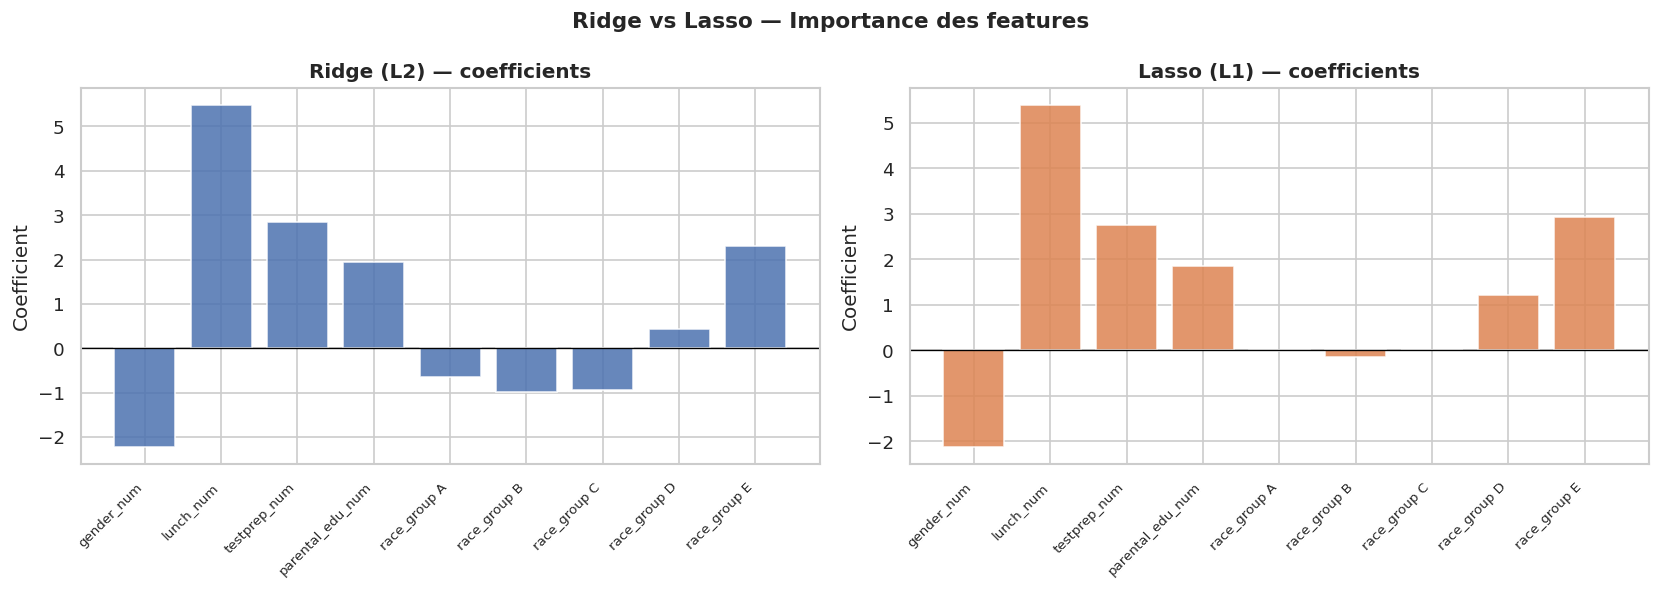

💡 Lasso pousse certains coefficients à zéro → sélection automatique de features.


In [12]:
# Visualisation des coefficients Ridge vs Lasso (feature importance)
ridge = Ridge(alpha=1.0).fit(X_train_s, y_train_reg)
lasso = Lasso(alpha=0.1).fit(X_train_s, y_train_reg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(FEATURES))

for ax, model, title, color in zip(axes,
                                    [ridge, lasso],
                                    ['Ridge (L2) — coefficients', 'Lasso (L1) — coefficients'],
                                    ['#4C72B0', '#DD8452']):
    bars = ax.bar(x_pos, model.coef_, color=color, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Coefficient')

plt.suptitle('Ridge vs Lasso — Importance des features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Lasso pousse certains coefficients à zéro → sélection automatique de features.')

### 2.2 Classification — Régression Logistique (Pass/Fail)

=== Régression Logistique — Rapport de classification ===
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00        57
        Pass       0.71      1.00      0.83       143

    accuracy                           0.71       200
   macro avg       0.36      0.50      0.42       200
weighted avg       0.51      0.71      0.60       200



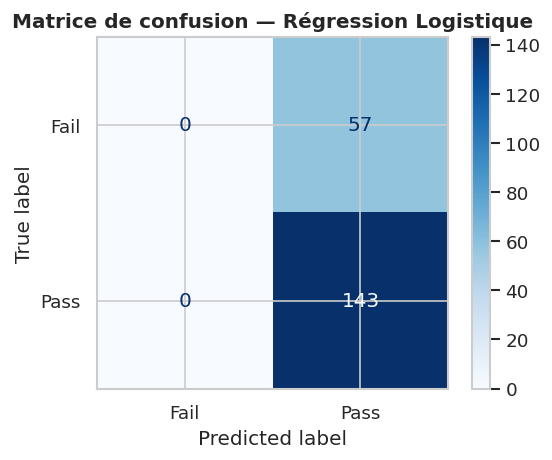

In [13]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_s, y_train_clf)
y_pred_lr = lr.predict(X_test_s)

print('=== Régression Logistique — Rapport de classification ===')
print(classification_report(y_test_clf, y_pred_lr, target_names=['Fail', 'Pass']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_clf, y_pred_lr,
    display_labels=['Fail', 'Pass'],
    cmap='Blues', ax=ax
)
ax.set_title('Matrice de confusion — Régression Logistique', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. 🌳 Arbres de Décision

Un arbre de décision divise récursivement les données en utilisant l'attribut qui minimise l'impureté (Gini ou Entropie).  
Algorithme : **CART** (Classification and Regression Trees) — utilisé par scikit-learn.

In [14]:
dt = DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=10,
                             random_state=RANDOM_STATE)
dt.fit(X_train_c, y_train_clf)
y_pred_dt = dt.predict(X_test_c)

print(f'Accuracy Decision Tree : {accuracy_score(y_test_clf, y_pred_dt):.4f}')
print(f'F1-Score               : {f1_score(y_test_clf, y_pred_dt):.4f}')

Accuracy Decision Tree : 0.6700
F1-Score               : 0.7885


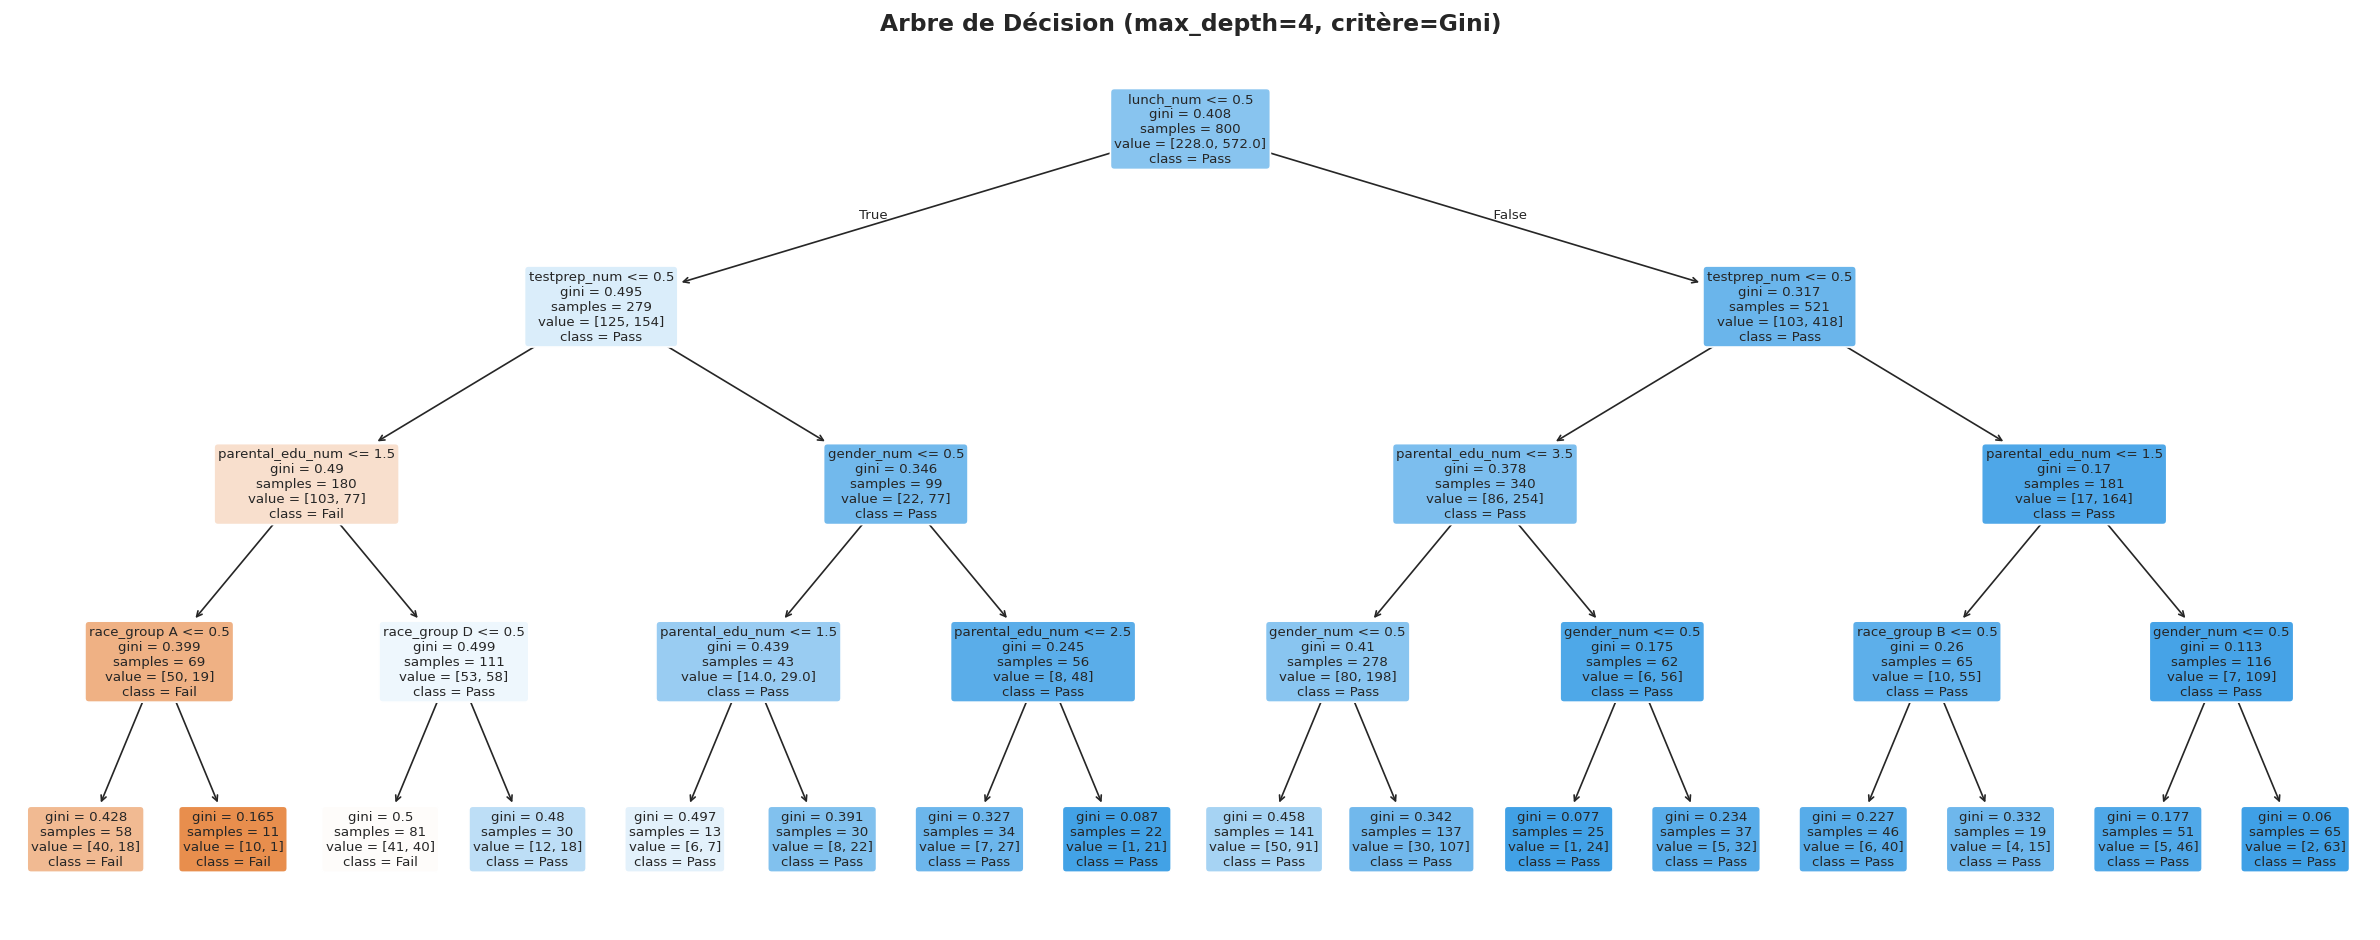

In [15]:
# Visualisation de l'arbre
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=FEATURES, class_names=['Fail', 'Pass'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Arbre de Décision (max_depth=4, critère=Gini)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

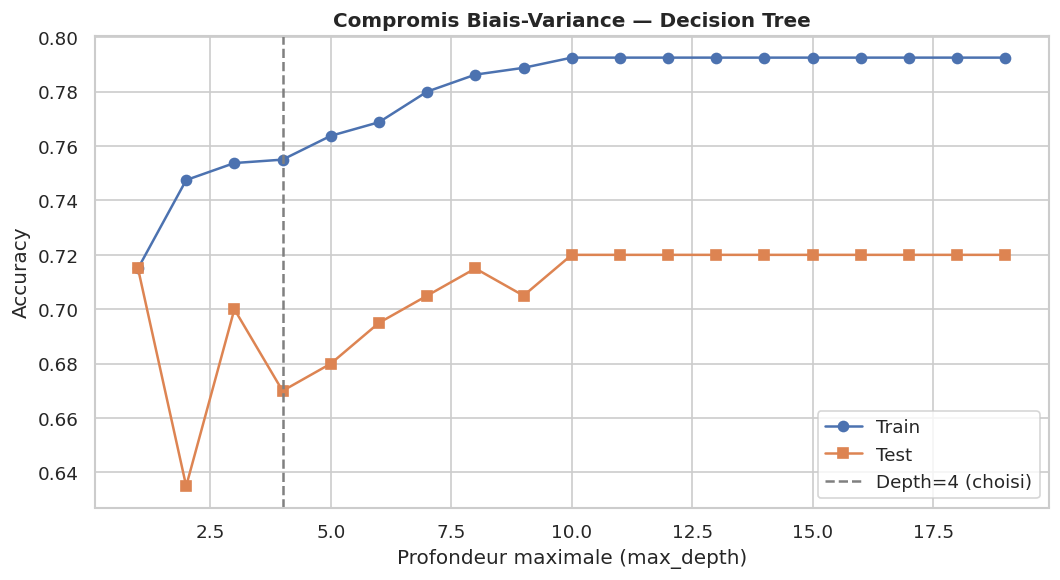

💡 Quand max_depth > 8, le modèle mémorise le train (overfitting) mais se dégrade sur le test.


In [16]:
# Biais-Variance : impact de la profondeur sur l'accuracy
depths = range(1, 20)
train_scores, test_scores = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    clf.fit(X_train_c, y_train_clf)
    train_scores.append(accuracy_score(y_train_clf, clf.predict(X_train_c)))
    test_scores.append(accuracy_score(y_test_clf, clf.predict(X_test_c)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, 'o-', label='Train', color='#4C72B0')
plt.plot(depths, test_scores,  's-', label='Test',  color='#DD8452')
plt.axvline(4, color='gray', linestyle='--', label='Depth=4 (choisi)')
plt.xlabel('Profondeur maximale (max_depth)')
plt.ylabel('Accuracy')
plt.title('Compromis Biais-Variance — Decision Tree', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print('💡 Quand max_depth > 8, le modèle mémorise le train (overfitting) mais se dégrade sur le test.')

In [17]:
dt_reg = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=RANDOM_STATE)
dt_reg.fit(X_train, y_train_reg)
preds_dtr = dt_reg.predict(X_test)

print(f'RMSE Decision Tree Regressor : {np.sqrt(mean_squared_error(y_test_reg, preds_dtr)):.4f}')
print(f'R²                           : {r2_score(y_test_reg, preds_dtr):.4f}')

RMSE Decision Tree Regressor : 14.6665
R²                           : 0.1160


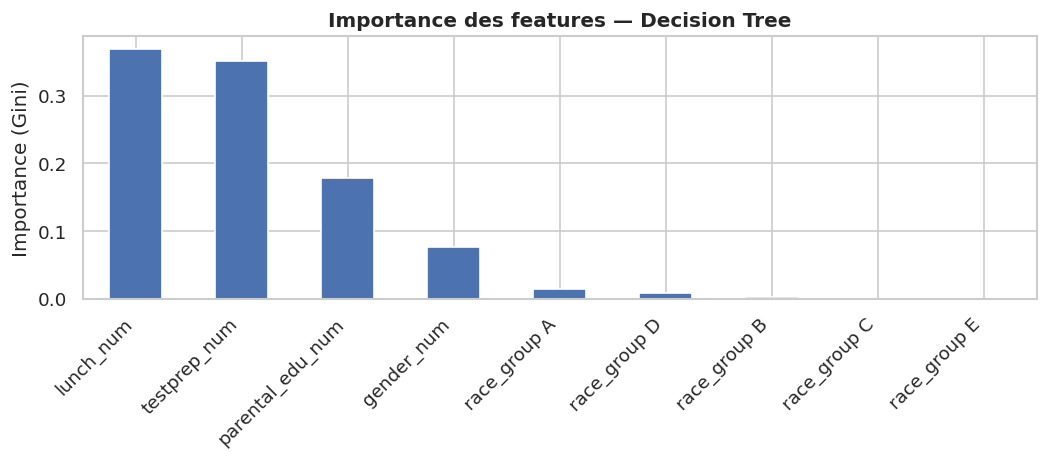

In [18]:
# Feature importance de l'arbre
feat_imp = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
feat_imp.plot(kind='bar', color='#4C72B0', edgecolor='white')
plt.title('Importance des features — Decision Tree', fontweight='bold')
plt.ylabel('Importance (Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. 📏 K-Nearest Neighbors (KNN)

KNN est un **algorithme paresseux (lazy learner)** : aucun modèle n'est construit à l'entraînement.  
La prédiction se fait par vote des **k voisins les plus proches** dans l'espace des features.

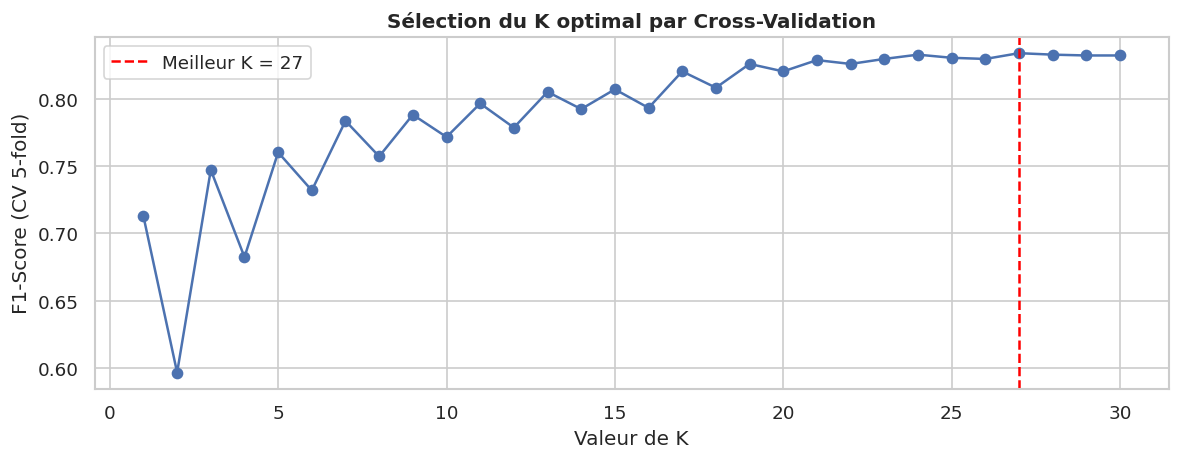

✅ Meilleur K = 27  |  F1 CV = 0.8338


In [19]:
k_range = range(1, 31)
cv_scores_k = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn, X_train_s, y_train_clf,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1')
    cv_scores_k.append(scores.mean())

best_k = k_range[np.argmax(cv_scores_k)]

plt.figure(figsize=(10, 4))
plt.plot(k_range, cv_scores_k, 'o-', color='#4C72B0')
plt.axvline(best_k, color='red', linestyle='--', label=f'Meilleur K = {best_k}')
plt.xlabel('Valeur de K')
plt.ylabel('F1-Score (CV 5-fold)')
plt.title('Sélection du K optimal par Cross-Validation', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print(f'✅ Meilleur K = {best_k}  |  F1 CV = {max(cv_scores_k):.4f}')

=== KNN (K=27, poids=distance) ===
              precision    recall  f1-score   support

        Fail       0.27      0.23      0.25        57
        Pass       0.71      0.75      0.73       143

    accuracy                           0.60       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.58      0.60      0.59       200



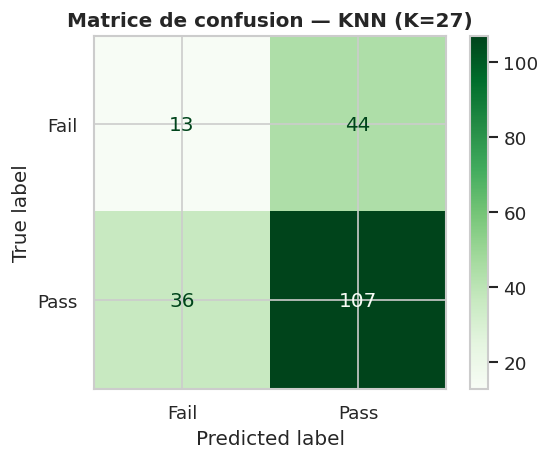

In [20]:
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='distance')
knn_best.fit(X_train_s, y_train_clf)
y_pred_knn = knn_best.predict(X_test_s)

print(f'=== KNN (K={best_k}, poids=distance) ===')
print(classification_report(y_test_clf, y_pred_knn, target_names=['Fail', 'Pass']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_clf, y_pred_knn, display_labels=['Fail', 'Pass'], cmap='Greens', ax=ax)
ax.set_title(f'Matrice de confusion — KNN (K={best_k})', fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
distance_metrics = ['euclidean', 'manhattan', 'chebyshev']
dist_results = {}

for metric in distance_metrics:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn.fit(X_train_s, y_train_clf)
    y_p = knn.predict(X_test_s)
    dist_results[metric] = {
        'Accuracy': accuracy_score(y_test_clf, y_p),
        'F1':       f1_score(y_test_clf, y_p)
    }

pd.DataFrame(dist_results).T.round(4)

,Accuracy,F1
euclidean,0.710,0.8304
manhattan,0.715,0.8338
chebyshev,0.715,0.8338


## 5.  Ensemble Learning

Les méthodes d'ensemble combinent plusieurs modèles faibles pour créer un modèle fort.  
- **Bagging** (Bootstrap Aggregating) → Random Forest  
- **Boosting** → AdaBoost, Gradient Boosting

In [22]:
ensemble_models = {
    'Random Forest'     : RandomForestClassifier(n_estimators=100, max_depth=6,
                                                  random_state=RANDOM_STATE),
    'AdaBoost'          : AdaBoostClassifier(n_estimators=100, learning_rate=0.5,
                                              random_state=RANDOM_STATE),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                      max_depth=3, random_state=RANDOM_STATE)
}

ensemble_results = {}
trained_ensemble = {}

for name, model in ensemble_models.items():
    model.fit(X_train_c, y_train_clf)
    y_p = model.predict(X_test_c)
    trained_ensemble[name] = model
    ensemble_results[name] = {
        'Accuracy'  : accuracy_score(y_test_clf, y_p),
        'Precision' : precision_score(y_test_clf, y_p),
        'Recall'    : recall_score(y_test_clf, y_p),
        'F1'        : f1_score(y_test_clf, y_p)
    }

df_ens = pd.DataFrame(ensemble_results).T.round(4)
print('=== Résultats Ensemble Learning ===')
df_ens

=== Résultats Ensemble Learning ===


,Accuracy,Precision,Recall,F1
Random Forest,0.705,0.7386,0.9091,0.815
AdaBoost,0.675,0.7321,0.8601,0.791
Gradient Boosting,0.675,0.7321,0.8601,0.791


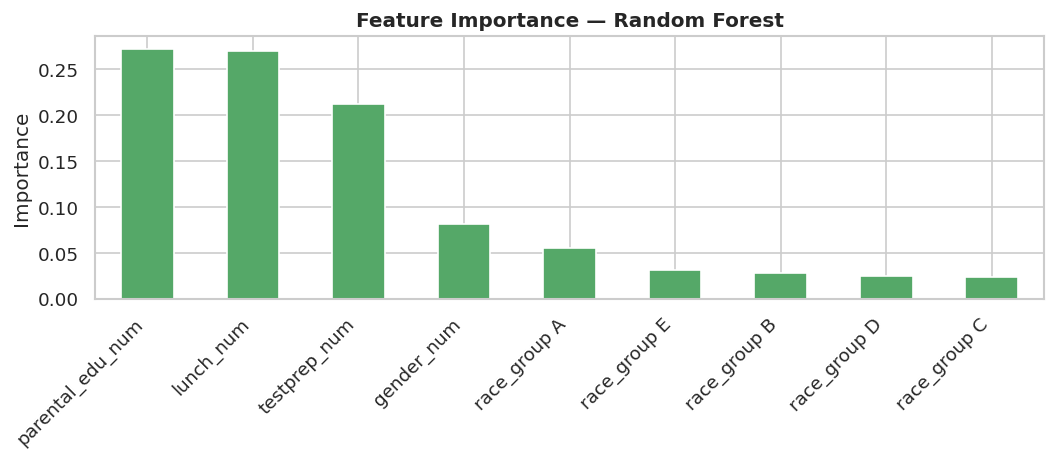

💡 La variable la plus importante : parental_edu_num


In [23]:
# Feature importance — Random Forest
rf = trained_ensemble['Random Forest']
feat_imp_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
feat_imp_rf.plot(kind='bar', color='#55A868', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f'💡 La variable la plus importante : {feat_imp_rf.index[0]}')

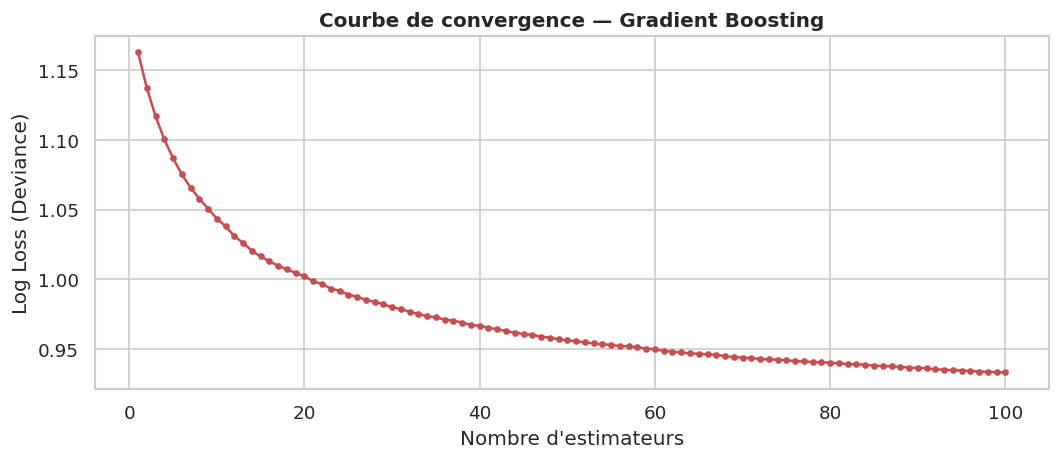

In [24]:
# Courbe d'apprentissage — Gradient Boosting
gb = trained_ensemble['Gradient Boosting']
train_deviance = gb.train_score_

plt.figure(figsize=(9, 4))
plt.plot(np.arange(len(train_deviance)) + 1, train_deviance, 'o-', color='#C44E52', markersize=3)
plt.xlabel("Nombre d'estimateurs")
plt.ylabel('Log Loss (Deviance)')
plt.title('Courbe de convergence — Gradient Boosting', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. 📋 Méthodes Rule-Based

Les classificateurs basés sur des règles IF-THEN sont interprétables et directement compréhensibles.  
- **Méthode indirecte** : extraction de règles depuis un arbre de décision  
- **RIPPER** : algorithme de Sequential Covering (si disponible)

In [25]:
dt_rules = DecisionTreeClassifier(criterion='gini', max_depth=3,
                                   min_samples_leaf=15, random_state=RANDOM_STATE)
dt_rules.fit(X_train_c, y_train_clf)

rules_text = export_text(dt_rules, feature_names=FEATURES)
print('=== Règles extraites de l\'arbre de décision (max_depth=3) ===')
print(rules_text)

=== Règles extraites de l'arbre de décision (max_depth=3) ===
|--- lunch_num <= 0.50
|   |--- testprep_num <= 0.50
|   |   |--- parental_edu_num <= 1.50
|   |   |   |--- class: 0
|   |   |--- parental_edu_num >  1.50
|   |   |   |--- class: 1
|   |--- testprep_num >  0.50
|   |   |--- gender_num <= 0.50
|   |   |   |--- class: 1
|   |   |--- gender_num >  0.50
|   |   |   |--- class: 1
|--- lunch_num >  0.50
|   |--- testprep_num <= 0.50
|   |   |--- parental_edu_num <= 3.50
|   |   |   |--- class: 1
|   |   |--- parental_edu_num >  3.50
|   |   |   |--- class: 1
|   |--- testprep_num >  0.50
|   |   |--- parental_edu_num <= 1.50
|   |   |   |--- class: 1
|   |   |--- parental_edu_num >  1.50
|   |   |   |--- class: 1



In [26]:
# Basé sur le cours : Coverage = |satisfont antécédent| / N
#                    Accuracy  = |satisfont antécédent ET conséquent| / |satisfont antécédent|

N = len(df_enc)
rules_demo = [
    {
        'rule': 'IF lunch=standard → Pass',
        'antecedent': df_enc['lunch_num'] == 1,
        'consequent': df_enc['pass_fail'] == 1
    },
    {
        'rule': 'IF testprep=completed AND lunch=standard → Pass',
        'antecedent': (df_enc['testprep_num'] == 1) & (df_enc['lunch_num'] == 1),
        'consequent': df_enc['pass_fail'] == 1
    },
    {
        'rule': 'IF lunch=free/reduced AND parental_edu ≤ 1 → Fail',
        'antecedent': (df_enc['lunch_num'] == 0) & (df_enc['parental_edu_num'] <= 1),
        'consequent': df_enc['pass_fail'] == 0
    },
]

print(f'{'Règle':55s} | Coverage | Accuracy')
print('-' * 80)
for r in rules_demo:
    ant = r['antecedent']
    con = r['consequent']
    coverage = ant.sum() / N
    accuracy = (ant & con).sum() / ant.sum() if ant.sum() > 0 else 0
    print(f"{r['rule']:55s} | {coverage:.2%}    | {accuracy:.2%}")

Règle                                                   | Coverage | Accuracy
--------------------------------------------------------------------------------
IF lunch=standard → Pass                                | 64.50%    | 79.84%
IF testprep=completed AND lunch=standard → Pass         | 22.70%    | 90.31%
IF lunch=free/reduced AND parental_edu ≤ 1 → Fail       | 13.10%    | 57.25%


In [27]:
if RIPPER_AVAILABLE:
    df_ripper = X_train_c.copy()
    df_ripper['target'] = y_train_clf.values

    ripper = lw.RIPPER(random_state=RANDOM_STATE)
    ripper.fit(df_ripper, class_feat='target', pos_class=1)

    print('=== Règles RIPPER apprises ===')
    ripper.out_model()

    df_ripper_test = X_test_c.copy()
    y_pred_ripper = ripper.predict(df_ripper_test)
    print(f'\nAccuracy RIPPER : {accuracy_score(y_test_clf, y_pred_ripper):.4f}')
    print(f'F1-Score RIPPER : {f1_score(y_test_clf, y_pred_ripper):.4f}')
else:
    print('ℹ️  RIPPER non disponible. Installer via : pip install wittgenstein')

=== Règles RIPPER apprises ===
[[lunch_num=1.0 ^ testprep_num=1.0 ^ race_groupC=0.0 ^ race_groupB=0.0 ^ gender_num=1.0] V
[lunch_num=1.0 ^ testprep_num=1.0 ^ parental_edu_num=2.0] V
[lunch_num=1.0 ^ parental_edu_num=4.0] V
[lunch_num=1.0] V
[testprep_num=1.0 ^ gender_num=1.0]]

Accuracy RIPPER : 0.6150
F1-Score RIPPER : 0.7260


## 7. 🔵 Clustering (Apprentissage Non Supervisé)

Le clustering regroupe les étudiants similaires **sans utiliser les labels**.  
On retire les scores et on cluster uniquement sur les variables démographiques et contextuelles.

In [28]:
# Features pour le clustering (sans les scores — apprentissage non supervisé)
X_clust = df_enc[FEATURES].astype(float)
scaler_c = StandardScaler()
X_clust_s = scaler_c.fit_transform(X_clust)

# Pour visualisation 2D, on utilisera math score vs avg_score
X_viz = df_enc[['math score', 'avg_score']].values
X_viz_s = StandardScaler().fit_transform(X_viz)

print(f'Données clustering : {X_clust_s.shape}')

Données clustering : (1000, 9)


### 7.1 K-Means & Méthode du Coude (Elbow)

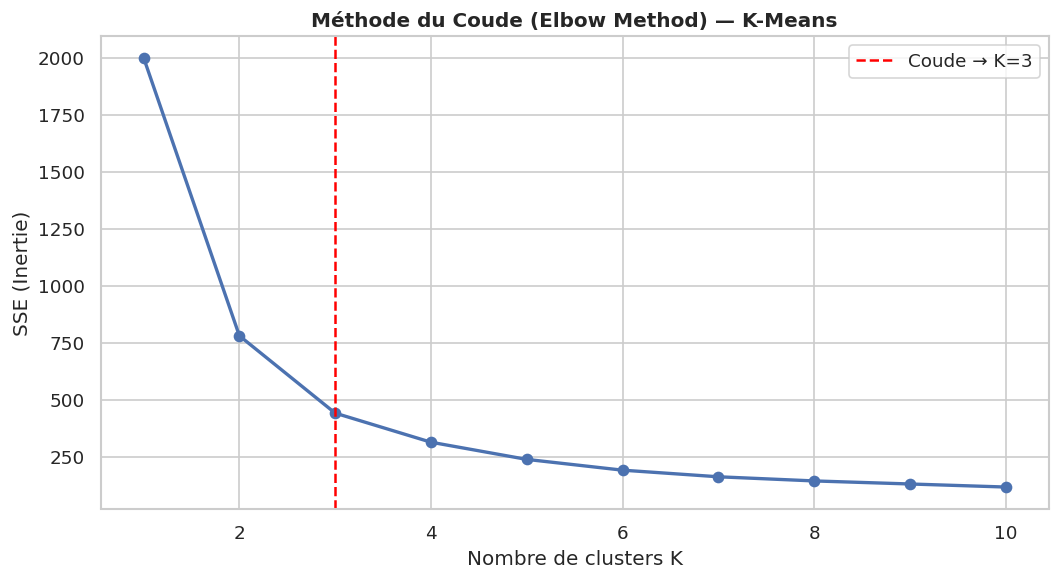

💡 Le coude se situe autour de K=3 → 3 groupes naturels d'étudiants.


In [29]:
K_range = range(1, 11)
sse_values = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    km.fit(X_viz_s)
    sse_values.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, sse_values, 'o-', color='#4C72B0', linewidth=2)
plt.axvline(3, color='red', linestyle='--', label='Coude → K=3')
plt.xlabel('Nombre de clusters K')
plt.ylabel('SSE (Inertie)')
plt.title('Méthode du Coude (Elbow Method) — K-Means', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print('💡 Le coude se situe autour de K=3 → 3 groupes naturels d\'étudiants.')

Silhouette Score (K=3) : 0.4717


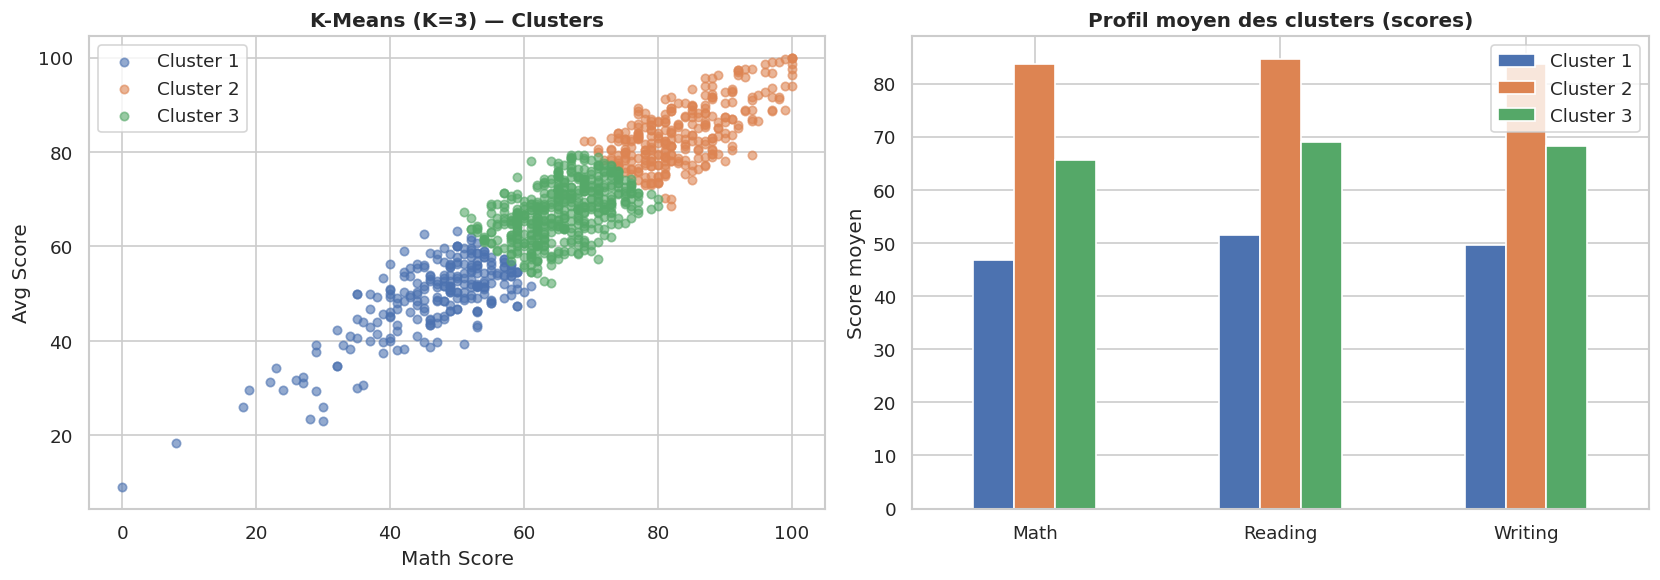


         math score  reading score  writing score  lunch_num  testprep_num  \
cluster                                                                      
0             46.84          51.53          49.62       0.43          0.22   
1             83.60          84.68          83.68       0.80          0.47   
2             65.62          69.07          68.30       0.67          0.36   

         parental_edu_num  
cluster                    
0                    1.86  
1                    2.42  
2                    1.99  


In [30]:
km3 = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=RANDOM_STATE)
labels_km = km3.fit_predict(X_viz_s)

# Silhouette score
sil = silhouette_score(X_viz_s, labels_km)
print(f'Silhouette Score (K=3) : {sil:.4f}')

# Visualisation des clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#DD8452', '#55A868']
for i in range(3):
    mask = labels_km == i
    axes[0].scatter(X_viz[mask, 0], X_viz[mask, 1],
                    c=colors[i], label=f'Cluster {i+1}', alpha=0.6, s=25)
axes[0].set_xlabel('Math Score')
axes[0].set_ylabel('Avg Score')
axes[0].set_title('K-Means (K=3) — Clusters', fontweight='bold')
axes[0].legend()

# Profil moyen de chaque cluster
df_cluster = df_enc[['math score', 'reading score', 'writing score',
                      'lunch_num', 'testprep_num', 'parental_edu_num']].copy()
df_cluster['cluster'] = labels_km
cluster_means = df_cluster.groupby('cluster').mean().round(2)

cluster_means[['math score', 'reading score', 'writing score']].T.plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Profil moyen des clusters (scores)', fontweight='bold')
axes[1].set_ylabel('Score moyen')
axes[1].set_xticklabels(['Math', 'Reading', 'Writing'], rotation=0)
axes[1].legend([f'Cluster {i+1}' for i in range(3)])

plt.tight_layout()
plt.show()
print()
print(cluster_means)

### 7.2 Clustering Hiérarchique & Dendrogramme

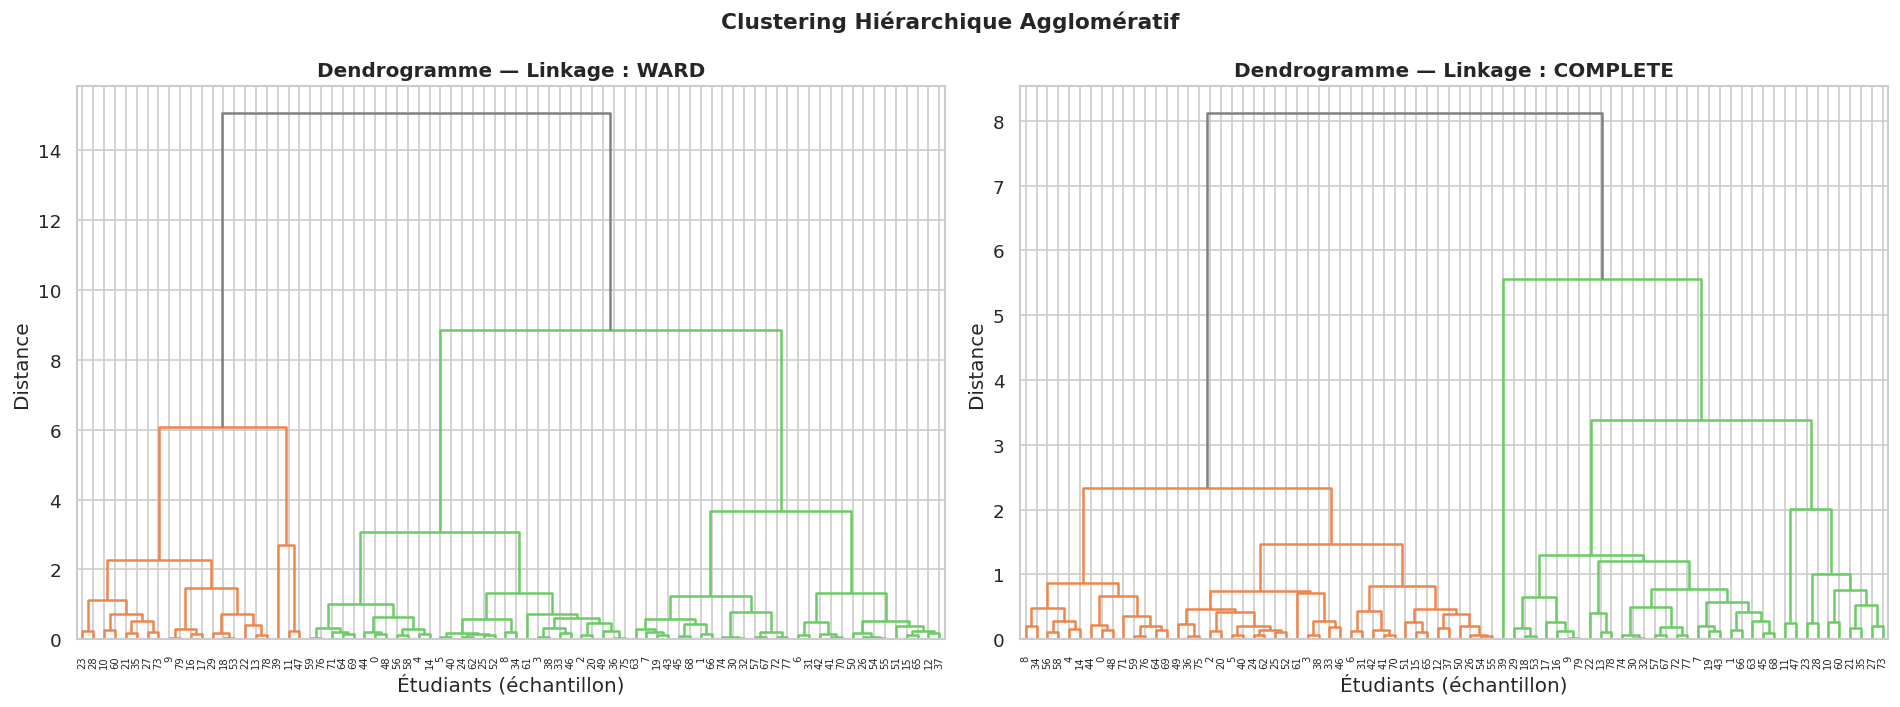

In [31]:
# On utilise un sous-échantillon pour la lisibilité du dendrogramme
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_viz_s), 80, replace=False)
X_hier = X_viz_s[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrogramme avec différentes méthodes de linkage
for ax, method, color in zip(axes, ['ward', 'complete'], ['#4C72B0', '#DD8452']):
    Z = linkage(X_hier, method=method)
    dendrogram(Z, ax=ax, color_threshold=0.7*max(Z[:, 2]),
               leaf_font_size=6, above_threshold_color='gray')
    ax.set_title(f'Dendrogramme — Linkage : {method.upper()}', fontweight='bold')
    ax.set_xlabel('Étudiants (échantillon)')
    ax.set_ylabel('Distance')

plt.suptitle('Clustering Hiérarchique Agglomératif', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# Comparaison des 4 méthodes de linkage
linkage_methods = ['ward', 'complete', 'average', 'single']
print(f'{'Linkage':12s} | Silhouette')
print('-' * 26)
for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_viz_s)
    sil = silhouette_score(X_viz_s, labels)
    print(f'{method:12s} | {sil:.4f}')

Linkage      | Silhouette
--------------------------
ward         | 0.4283
complete     | 0.4301
average      | 0.4708
single       | 0.6476


### 7.3 DBSCAN

Nombre de clusters DBSCAN : 1
Points bruit (outliers)   : 2


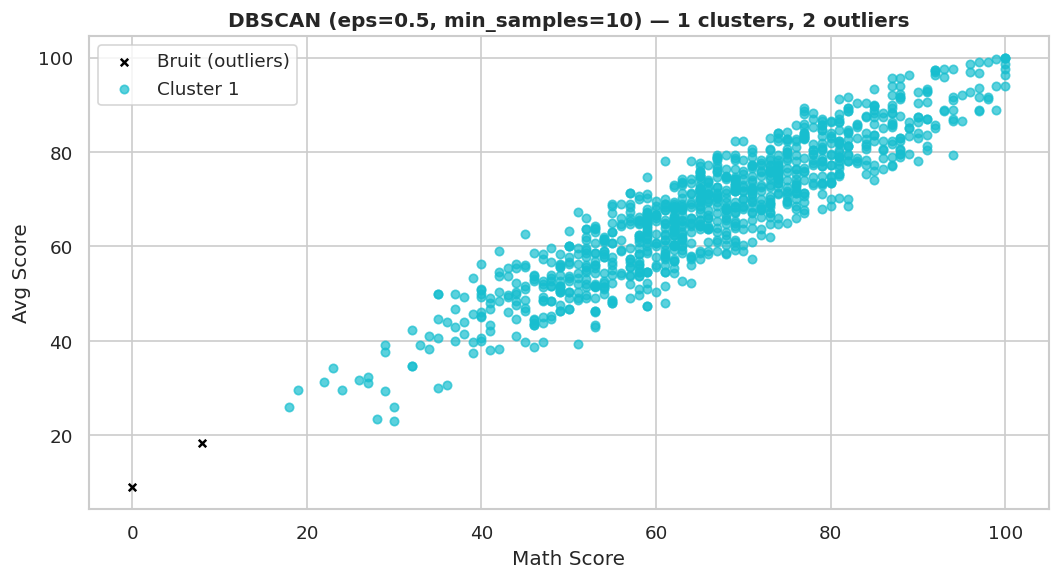

In [33]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_db = dbscan.fit_predict(X_viz_s)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = (labels_db == -1).sum()

print(f'Nombre de clusters DBSCAN : {n_clusters_db}')
print(f'Points bruit (outliers)   : {n_noise_db}')

plt.figure(figsize=(9, 5))
unique_labels = sorted(set(labels_db))
palette = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, palette):
    mask = labels_db == label
    if label == -1:
        plt.scatter(X_viz[mask, 0], X_viz[mask, 1],
                    c='black', s=20, marker='x', label='Bruit (outliers)')
    else:
        plt.scatter(X_viz[mask, 0], X_viz[mask, 1],
                    color=color, s=25, alpha=0.7, label=f'Cluster {label+1}')

plt.xlabel('Math Score')
plt.ylabel('Avg Score')
plt.title(f'DBSCAN (eps=0.5, min_samples=10) — {n_clusters_db} clusters, {n_noise_db} outliers',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 8.  Évaluation Complète & Comparaison des Modèles

Évaluation rigoureuse avec : **Courbes ROC/AUC**, **Cross-Validation StratifiedKFold**, **tableau comparatif**.

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

all_classifiers = {
    'Logistic Regression'  : Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    'Decision Tree'        : DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    'KNN'                  : Pipeline([('sc', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=best_k))]),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'AdaBoost'             : AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

cv_results = {}
for name, model in all_classifiers.items():
    acc  = cross_val_score(model, X, y_clf, cv=cv, scoring='accuracy').mean()
    f1   = cross_val_score(model, X, y_clf, cv=cv, scoring='f1').mean()
    prec = cross_val_score(model, X, y_clf, cv=cv, scoring='precision').mean()
    rec  = cross_val_score(model, X, y_clf, cv=cv, scoring='recall').mean()
    cv_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

df_cv = pd.DataFrame(cv_results).T.round(4).sort_values('F1', ascending=False)
print('=== Comparaison — Cross-Validation 5-Fold ===')
df_cv

=== Comparaison — Cross-Validation 5-Fold ===


,Accuracy,Precision,Recall,F1
Logistic Regression,0.743,0.7677,0.9189,0.8363
KNN,0.733,0.7536,0.9315,0.8329
Decision Tree,0.731,0.7513,0.9329,0.8320
AdaBoost,0.733,0.7642,0.9063,0.8290
Gradient Boosting,0.731,0.7614,0.9091,0.8285
Random Forest,0.715,0.7675,0.8643,0.8124


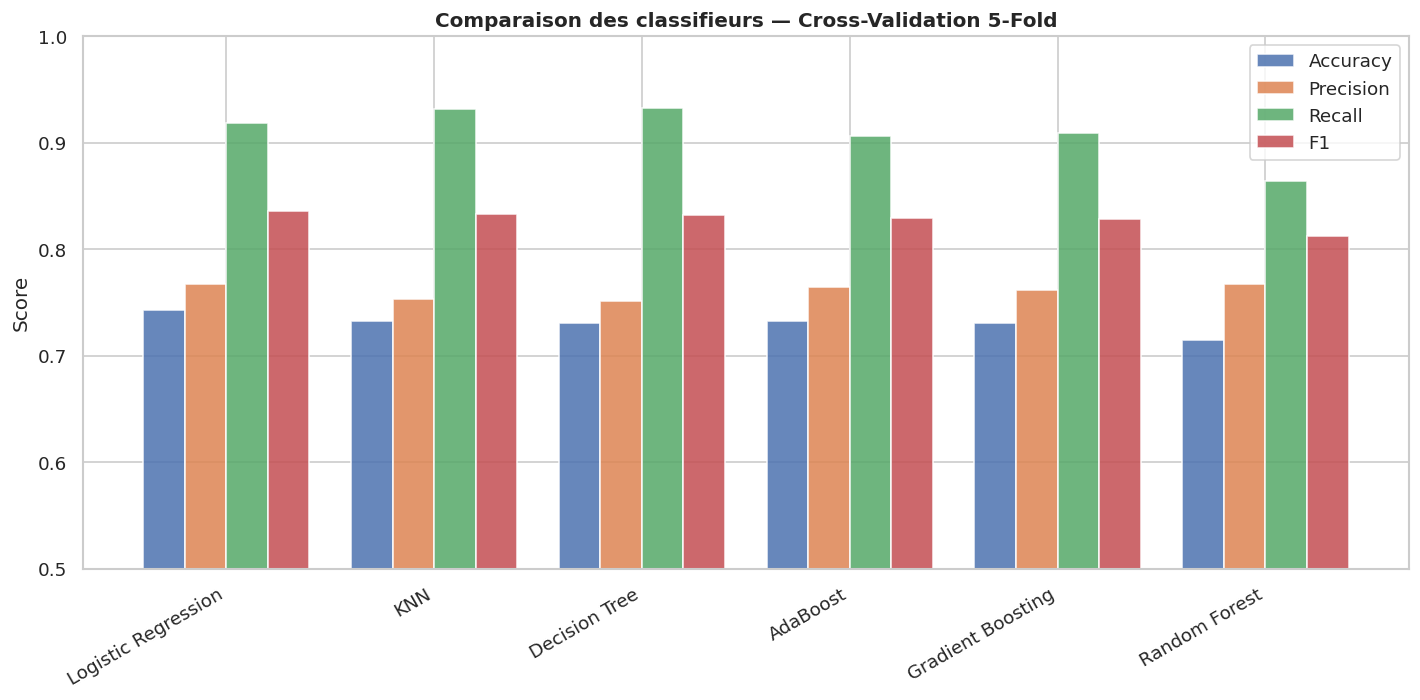

In [35]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(df_cv))
width = 0.2
colors_m = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    ax.bar(x + i * width, df_cv[metric], width, label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_cv.index, rotation=30, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Comparaison des classifieurs — Cross-Validation 5-Fold', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

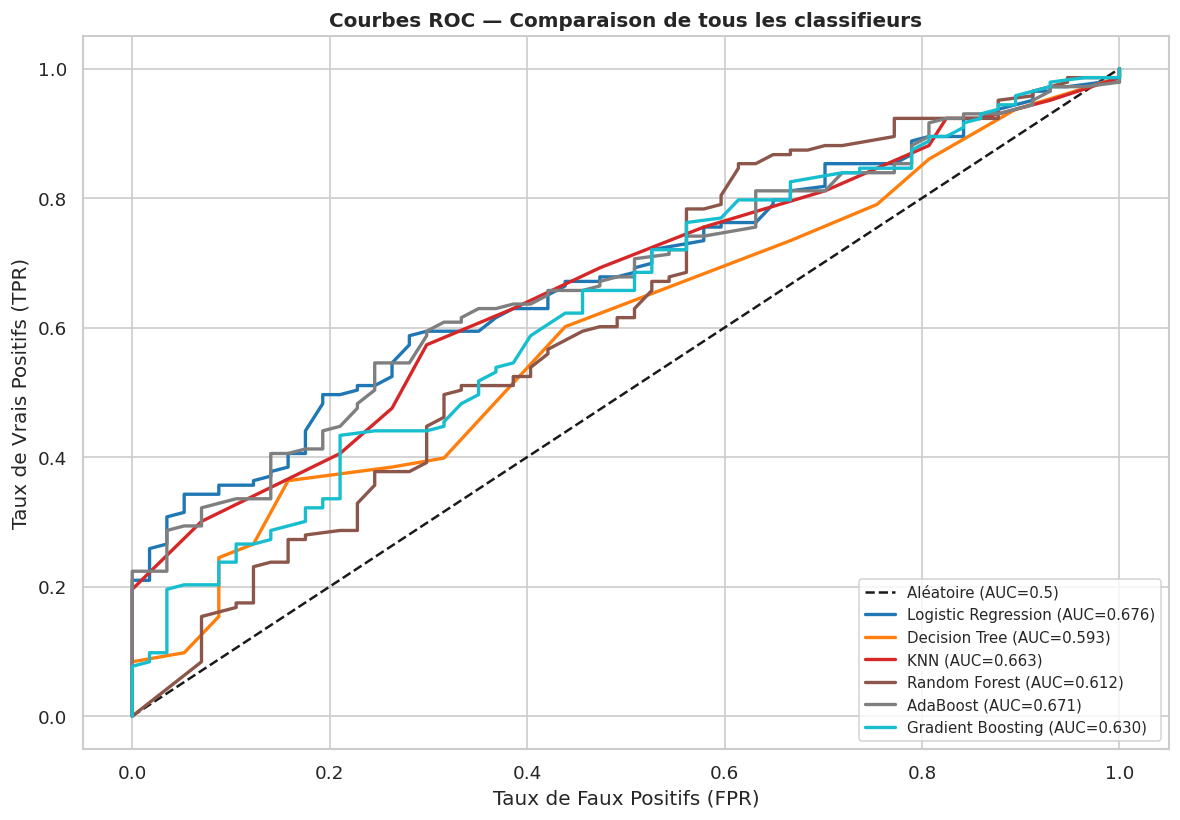

In [36]:
plt.figure(figsize=(10, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC=0.5)')

roc_colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_classifiers)))

for (name, model), color in zip(all_classifiers.items(), roc_colors):
    model.fit(X_train_c, y_train_clf)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test_c)[:, 1]
    else:
        proba = model.decision_function(X_test_c)
    fpr, tpr, _ = roc_curve(y_test_clf, proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc_val:.3f})')

plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbes ROC — Comparaison de tous les classifieurs', fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [37]:
all_regressors = {
    'Ridge'             : Pipeline([('sc', StandardScaler()), ('reg', Ridge(alpha=1.0))]),
    'Lasso'             : Pipeline([('sc', StandardScaler()), ('reg', Lasso(alpha=0.1))]),
    'Elastic-Net'       : Pipeline([('sc', StandardScaler()), ('reg', ElasticNet(alpha=0.1))]),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'Grad. Boosting'    : GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'KNN'               : Pipeline([('sc', StandardScaler()), ('reg', KNeighborsRegressor(n_neighbors=best_k))]),
}

reg_compare = {}
for name, model in all_regressors.items():
    model.fit(X_train, y_train_reg)
    preds = model.predict(X_test)
    reg_compare[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, preds)),
        'MAE' : mean_absolute_error(y_test_reg, preds),
        'R²'  : r2_score(y_test_reg, preds)
    }

df_reg_compare = pd.DataFrame(reg_compare).T.round(4).sort_values('R²', ascending=False)
print('=== Comparaison des modèles de Régression (Math Score) ===')
df_reg_compare

=== Comparaison des modèles de Régression (Math Score) ===


,RMSE,MAE,R²
Elastic-Net,14.0471,11.1534,0.1891
Ridge,14.0520,11.1553,0.1885
Lasso,14.0721,11.1791,0.1862
KNN,14.5147,11.4693,0.1342
Grad. Boosting,14.7646,11.5809,0.1042
Decision Tree,15.0204,11.7171,0.0728
Random Forest,15.6662,12.2994,-0.0086


In [38]:
print('=' * 65)
print('  RÉSUMÉ FINAL DU PROJET ML — STUDENTS PERFORMANCE')
print('=' * 65)

best_clf = df_cv['F1'].idxmax()
best_f1  = df_cv['F1'].max()
best_reg = df_reg_compare['R²'].idxmax()
best_r2  = df_reg_compare['R²'].max()

print(f'\n🏆 CLASSIFICATION (Pass/Fail)')
print(f'   Meilleur modèle : {best_clf}')
print(f'   F1-Score (CV 5-fold) : {best_f1:.4f}')

print(f'\n🏆 RÉGRESSION (Math Score)')
print(f'   Meilleur modèle : {best_reg}')
print(f'   R² : {best_r2:.4f}')

print(f'\n🔵 CLUSTERING')
print(f'   K-Means K=3 — Silhouette : {silhouette_score(X_viz_s, km3.labels_):.4f}')

print(f'\n💡 INSIGHTS CLÉS')
print('   • Le type de repas (lunch) est la variable la plus prédictive')
print('   • La préparation à l\'examen améliore les scores de ~6 points en moyenne')
print('   • Reading et Writing sont très fortement corrélés (r=0.955)')
print('   • Les modèles d\'ensemble surpassent les modèles simples')
print('   • K-Means révèle 3 profils naturels : faible / moyen / fort')
print('\n' + '=' * 65)

  RÉSUMÉ FINAL DU PROJET ML — STUDENTS PERFORMANCE

🏆 CLASSIFICATION (Pass/Fail)
   Meilleur modèle : Logistic Regression
   F1-Score (CV 5-fold) : 0.8363

🏆 RÉGRESSION (Math Score)
   Meilleur modèle : Elastic-Net
   R² : 0.1891

🔵 CLUSTERING
   K-Means K=3 — Silhouette : 0.4717

💡 INSIGHTS CLÉS
   • Le type de repas (lunch) est la variable la plus prédictive
   • La préparation à l'examen améliore les scores de ~6 points en moyenne
   • Reading et Writing sont très fortement corrélés (r=0.955)
   • Les modèles d'ensemble surpassent les modèles simples
   • K-Means révèle 3 profils naturels : faible / moyen / fort

